In [1]:
from pathlib import Path
import pickle

import numpy as np
from scipy import constants as cst

import matplotlib.pyplot as plt
import tqdm

from centrex_tlf import states, hamiltonian, transitions, couplings, lindblad, utils
from centrex_tlf_julia_extension import lindblad_julia
import cv2
import numpy as np
from scipy.optimize import curve_fit
import scipy.ndimage as ndimage

from PIL import Image

In [2]:
plt.rcParams.update({"font.size": 14})

In [3]:
cwd = Path().cwd()

# Setting up the system

In [4]:
trans = [
    transitions.OpticalTransition(
        transitions.OpticalTransitionType.R, J_ground=2, F1=7 / 2, F=4
    )
]

polarizations = [[couplings.polarization_Z]]

transition_selectors = couplings.generate_transition_selectors(
    trans,
    polarizations,
    ground_mains=[
        1
        * states.CoupledBasisState(
            J=2,
            F=3,
            F1=5 / 2,
            mF=-1,
            I1=1 / 2,
            I2=1 / 2,
            Ω=0,
            P=+1,
            electronic_state=states.ElectronicState.X,
        )
    ],
    excited_mains=[
        1
        * states.CoupledBasisState(
            J=3,
            F=4,
            F1=7 / 2,
            mF=-1,
            I1=1 / 2,
            I2=1 / 2,
            Ω=1,
            P=-1,
            electronic_state=states.ElectronicState.B,
        )
    ],
)

In [24]:
v_to_Γ = utils.detuning.velocity_to_detuning(1)

odepars = lindblad_julia.odeParameters(
    Ω0="rabi_from_intensity(gaussian_2d_rotated(vz*t, y0+vy*t, peak_intensity, laser_center_z, laser_center_y, σz, σy, θ), main_coupling)",
    peak_intensity=1000.0,
    δ0=f"laser_detuning+vx*{v_to_Γ}",  # detuning of the laser [rad/s]
    # laser phase modulation
    ωphase=hamiltonian.Γ,  # laser phase modulation frequency [rad/s]
    β=0,  # laser phase modulation depth [rad]
    PZ0=1,
    # molecules
    z0=-0.03,  # molecule start z position [m]
    vz=184,  # longitudinal molecular velocity [m/s]
    vx=0,
    y0=0.0,
    vy=0.0,
    σz=4.53e-4,
    σy=1.04e-3,
    θ=0,
    laser_detuning = 0,
    laser_center_z=0,
    laser_center_y=0,
    main_coupling=0.5,
)


In [25]:
%%time
obe_system_original = lindblad.setup_OBE_system_transitions(
    trans, transition_selectors, verbose=True, qn_compact=True, decay_channels=None
)

INFO:centrex_tlf.lindblad.utils_setup:generate_OBE_system: 1/5 -> Generating the reduced Hamiltonian
INFO:centrex_tlf.lindblad.utils_setup:generate_OBE_system: 2/5 -> Generating the couplings corresponding to the transitions
INFO:centrex_tlf.lindblad.utils_setup:generate_OBE_system: 3/5 -> Generating the symbolic Hamiltonian
INFO:centrex_tlf.lindblad.utils_setup:generate_OBE_system: 4/5 -> Generating the collapse matrices
INFO:centrex_tlf.lindblad.utils_setup:generate_OBE_system: 5/5 -> Transforming the Hamiltonian and collapse matrices into a symbolic system of equations


CPU times: total: 13.4 s
Wall time: 40.3 s


In [26]:
from copy import deepcopy

obe_system_python = deepcopy(obe_system_original)

In [27]:
obe_system = lindblad_julia.setup_OBE_system_julia(
    obe_system_python, transition_selectors, odepars
)

## Detection Laser Beam Profile

### Read data from thorlabs beam profiler


## Beam profile after realignment with longer beamline


In [9]:

file_path = "beam_profile/2025-4-10-det-beamshape_#001.bmp"
# Open the image file
image = Image.open(file_path)

# Convert the image to grayscale (optional, if you need a 2D array)
image = image.convert('L')
# Convert the image to a NumPy array
image_array = np.array(image)
image_array = image_array[::-1, :]
sensor_array = image_array

# Converting the array to uint8 format needed for OpenCV
image = (sensor_array).astype(np.uint8)

# Apply thresholding to create a binary mask of the non-zero data
_, thresholded = cv2.threshold(image, 60, 255, cv2.THRESH_BINARY)

# Find contours of the thresholded image to locate the non-zero areas
contours, _ = cv2.findContours(thresholded, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Combine all contours into one to get a single enclosing circle
all_points = np.vstack(contours)

# Find the minimum enclosing circle that covers all combined contours
(x, y), radius = cv2.minEnclosingCircle(all_points)
center = (int(x), int(y))
radius = int(radius)

# Draw the enclosing circle on the original image
output_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)  # Convert to BGR for colored circle visualization
cv2.circle(output_image, center, radius, (0, 255, 0), 2)


pixel_x_size, pixel_y_size = 8.77e-3/1360, 6.6e-3/1024

# Define a 2D Gaussian function
def gaussian_2d(xy, amplitude, xo, yo, sigma_x, sigma_y):
    x, y = xy
    xo = float(xo)
    yo = float(yo)
    g = amplitude * np.exp(-(((x - xo) ** 2) / (2 * sigma_x ** 2) + ((y - yo) ** 2) / (2 * sigma_y ** 2)))
    return g.ravel()

# Define the 2D Gaussian function with rotation
def gaussian_2d_rotated(coords, A, x0, y0, sigma_x, sigma_y, theta):
    x, y = coords
    a = np.cos(theta)**2 / (2*sigma_x**2) + np.sin(theta)**2 / (2*sigma_y**2)
    b = np.sin(2*theta) / (2*sigma_x**2) - np.sin(2*theta) / (2*sigma_y**2)
    c = np.sin(theta)**2 / (2*sigma_x**2) + np.cos(theta)**2 / (2*sigma_y**2)

    g = A * np.exp(- a*(x-x0)**2 - b*(x-x0)*(y-y0) - c*(y-y0)**2)
    return g.ravel()

# Initial guess for the Gaussian parameters
initial_guess = (80, 600, 400, 200, 200, 2)  # (A, x0, y0, sigma_x, sigma_y, theta)
# initial_guess = (20, 600, 600, 20, 20)  # (A, x0, y0, sigma_x, sigma_y)

img = ndimage.gaussian_filter(sensor_array, sigma=(50, 50), order=0)

# Generate a grid of x, y coordinates
x = np.arange(img.shape[1])
y = np.arange(img.shape[0])
x, y = np.meshgrid(x, y)

# Create a mask to select data within the circle
mask = (x - center[0])**2 + (y - center[1])**2 <= radius**2

# Apply the mask to extract the relevant data
x_data = x[mask]
y_data = y[mask]
z_data = img[mask]


# Fit the Gaussian model to the data
popt, pcov = curve_fit(gaussian_2d_rotated, (x_data, y_data), z_data, p0=initial_guess, bounds=([-np.inf, -np.inf, -np.inf, -np.inf, -np.inf, 0], [np.inf, np.inf, np.inf, np.inf, np.inf, 2*np.pi]))
# popt, pcov = curve_fit(gaussian_2d, (x_data, y_data), z_data, p0=initial_guess)


# # Extract the fitted parameters
amplitude, xo, yo, sigma_x, sigma_y, theta = popt

# Generate fitted data for visualization
z_fitted = gaussian_2d_rotated((x, y), *popt).reshape(sensor_array.shape)


# # Plot fitted Gaussian
# fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(25, 6))
# scatter1 = ax1.scatter(x_data, y_data, c=sensor_array[mask], vmin=0, vmax=180, cmap='viridis')
# ax1.set_title('Raw Sensor Data')
# ax2.set_xlabel('Pixel X Index')
# ax2.set_ylabel('Pixel Y Index')
# fig.colorbar(scatter1, ax=ax1, label='Sensor Value')

# scatter2 = ax2.scatter(x_data, y_data, c=z_data, cmap='viridis')
# ax2.set_title('Smoothened Sensor Data')
# ax2.set_xlabel('Pixel X Index')
# ax2.set_ylabel('Pixel Y Index')
# fig.colorbar(scatter2, ax=ax2, label='Sensor Value')

# scatter3 = ax3.scatter(x_data, y_data, c=z_fitted[mask], cmap='viridis')
# ax3.set_title('Fitted 2D Gaussian')
# ax3.set_xlabel('Pixel X Index')
# ax3.set_ylabel('Pixel Y Index')     
# ax3.scatter(center[0], center[1], color='red', marker='o') 
# ax3.scatter(popt[1], popt[2], color='black', marker='x', label=f'Fitted Center x={(xo-center[0])*pixel_x_size*1e3:.2f}mm y={(yo-center[1])*pixel_y_size*1e3:.2f}mm') 
# ax3.plot(popt[1]+np.arange(-250,250,50)*np.sin(theta), popt[2]-np.arange(-250,250,50)*np.cos(theta), color='black', alpha=0.5, label=f'theta={int(theta*180/np.pi)}°')
# fig.colorbar(scatter3, ax=ax3, label='Sensor Value')
# ax3.legend()


In [10]:
popt

array([178.89608238, 639.96625573, 518.2031659 , 310.53050224,
       249.36447291,   1.65848691])

In [17]:
image.shape

(1024, 1360)

In [23]:
image.shape[0]*pixel_x_size

0.006603294117647059

In [10]:
(yo-center[1])*pixel_y_size

-1.1581157279483767e-05

In [11]:
sigma_x*pixel_x_size, sigma_y*pixel_y_size

(0.0020024650769411515, 0.0016072319542790225)

# Scan Frequency 

In [28]:
def get_diagonal_indices_flattened(size, states=None, mode="python"):
    if states is None:
        indices = [i + size * i for i in range(size)]
    else:
        indices = [i + size * i for i in states]
    if mode == "julia":
        return [i + 1 for i in indices]
    elif mode == "python":
        return indices
state_selector = states.QuantumSelector(electronic=states.ElectronicState.B)
indices = state_selector.get_indices(obe_system.QN)
save_idxs = get_diagonal_indices_flattened(len(obe_system.QN), indices, mode="julia")

## Run simulation

In [31]:
from rich import progress

def power_scan_function(laser_power):

    ρ = utils.population.generate_uniform_population_states(
        states.QuantumSelector(J=2, F=3, electronic=states.ElectronicState.X), obe_system.QN
    )
    stop_function = "vz*t + z0 >= 2e-2"

    callback = lindblad_julia.setup_discrete_callback_terminate(
        odepars=odepars, stop_expression=stop_function
    )
    odepars.σz, odepars.σy = sigma_x*pixel_x_size, sigma_y*pixel_y_size
    odepars.β = 0
    odepars.θ = theta
    odepars.laser_center_z, odepars.laser_center_y = -(xo-center[0])*pixel_x_size, (yo-center[1])*pixel_y_size
    power = laser_power*1e-3


    peak_intensity = power / (2 * np.pi * odepars.σz * odepars.σy)

    odepars.peak_intensity = peak_intensity

    ensemble_config = lindblad_julia.OBEEnsembleProblemConfig(
        method="Tsit5()",
        save_idxs=save_idxs,
        saveat=1e-6,
        abstol=1e-10,
        reltol=1e-7,
        callback=callback,
    )

    problem = lindblad_julia.OBEProblem(odepars, ρ, tspan=(0, 500e-6))
    frequencies = np.arange(-5, 5, 0.01) * 2 * np.pi * 1e6 * 4 

    scan_values = [frequencies]
    parameters = ["laser_detuning"]

    output_func = lindblad_julia.setup_state_integral_calculation_state_idxs(
        nphotons=True
    )

    ensemble_problem = lindblad_julia.OBEEnsembleProblem(
        problem=problem,
        parameters=parameters,
        scan_values=scan_values,
        output_func=output_func,
        zipped=True,
    )

    lindblad_julia.setup_problem_parameter_scan(ensemble_problem)

    lindblad_julia.solve_problem_parameter_scan(ensemble_problem, ensemble_config)

    results = lindblad_julia.get_results_parameter_scan(ensemble_problem)
    return (frequencies, results)
# with open("results_scan_freq.pkl", "wb") as f:
#     pickle.dump(results_scan, f)

  0%|          | 0/6 [00:00<?, ?it/s]

100%|██████████| 6/6 [01:14<00:00, 12.36s/it]


(-5.0, 5.0)

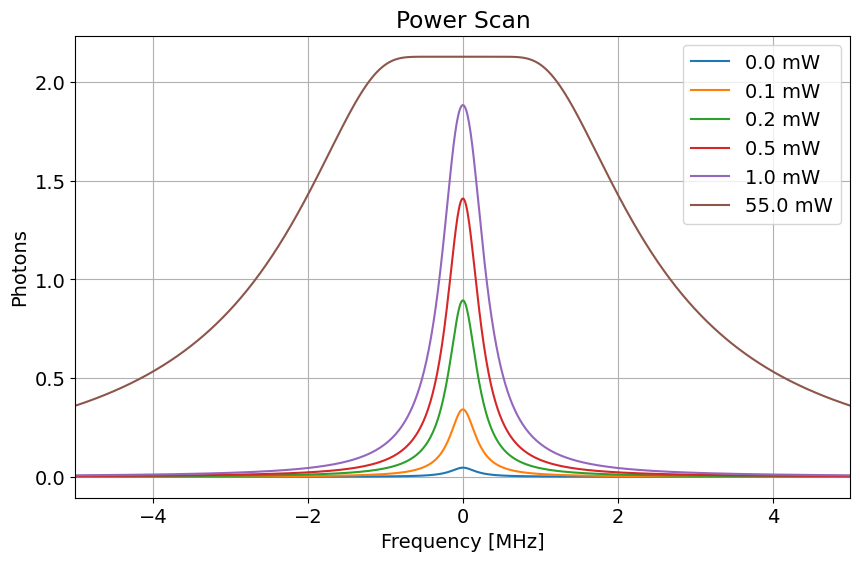

In [37]:
from scipy.integrate import simpson
import numpy as np
import numpy as np

def fwhm(freq, signal):
    """
    Return (FWHM, f_left, f_right) in the same units as `freq`.
    
    Parameters
    ----------
    freq : 1‑D array (monotonically increasing or decreasing)
    signal : 1‑D array of the same length
    
    Notes
    -----
    * Works for a single, well‑behaved peak.
    * Baseline is taken as the minimum of `signal`.
    """
    freq   = np.asarray(freq)
    signal = np.asarray(signal)

    # 1. baseline‑shift and normalise
    y = signal - signal.min()
    if y.ptp() == 0:
        raise ValueError("Signal is flat; cannot define FWHM.")
    y /= y.max()          # now max(y) == 1
    h = 0.5               # half‑maximum level

    # 2. index of peak
    i_peak = y.argmax()

    # 3a. left half‑height
    i_left = np.where(y[:i_peak] <= h)[0]
    if len(i_left) == 0:
        f_left = freq[0]
    else:
        i1 = i_left[-1]           # last point below 0.5
        i2 = i1 + 1               # first point above 0.5
        f_left = np.interp(h, [y[i1], y[i2]], [freq[i1], freq[i2]])

    # 3b. right half‑height
    i_right = np.where(y[i_peak:] <= h)[0]
    if len(i_right) == 0:
        f_right = freq[-1]
    else:
        i1 = i_right[0] + i_peak  # first point below 0.5 on the right
        i0 = i1 - 1               # point above 0.5
        f_right = np.interp(h, [y[i0], y[i1]], [freq[i0], freq[i1]])

    # 4. width
    width = abs(f_right - f_left)
    return width, f_left, f_right


laser_powers = [0.01, 0.08, 0.25, 0.5, 1, 55]
results_scan = {}
integrals = []
fwhms = []
fig, ax = plt.subplots(figsize=(10, 6))
for power in tqdm.tqdm(laser_powers):
    frequencies, results = power_scan_function(power)    
    # Assume: frequencies and results.results are given arrays
    frequencies = frequencies / (2 * np.pi * 1e6 * 4)  # scale frequencies

    fwhm_value, f_left, f_right = fwhm(frequencies, results.results)
    fwhms.append(fwhm_value)
    results_scan[power] = (frequencies, results)
    # Perform numerical integration
    integral = simpson(results.results, x=frequencies)
    integrals.append(integral)
    ax.plot(frequencies, results.results, label=f"{power:.1f} mW")
ax.set_xlabel("Frequency [MHz]")
ax.set_ylabel("Photons")
ax.set_title("Power Scan")
ax.legend()
ax.grid()
ax.set_xlim(-5, 5)




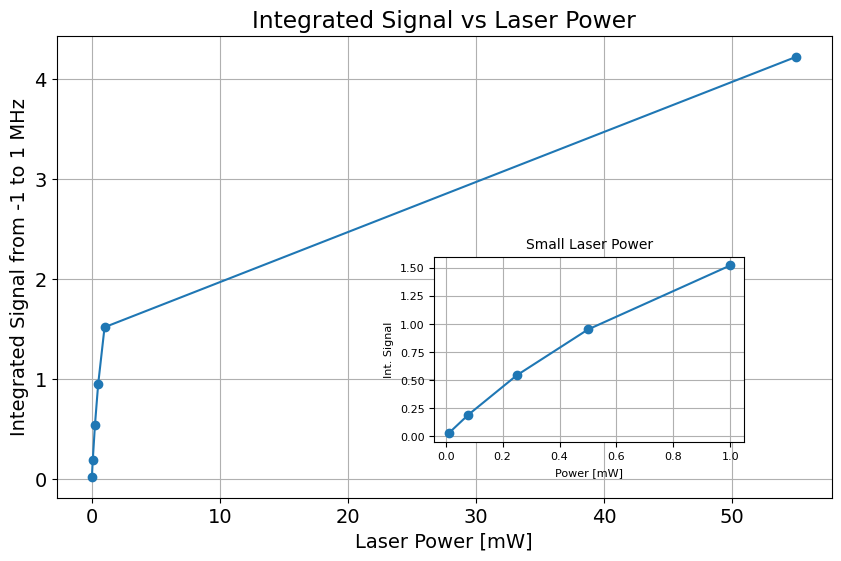

In [33]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(laser_powers, integrals, marker="o")
ax.set_xlabel("Laser Power [mW]")
ax.set_ylabel("Integrated Signal from -1 to 1 MHz")
ax.set_title("Integrated Signal vs Laser Power")
ax.grid()

inset_ax = inset_axes(ax, width="40%", height="40%", loc="lower right", bbox_to_anchor=(-0.1, 0.1, 1, 1), bbox_transform=ax.transAxes)
filtered_powers = [p for p in laser_powers if p <= 2]
filtered_integrals = [integrals[i] for i, p in enumerate(laser_powers) if p <= 2]

inset_ax.plot(filtered_powers, filtered_integrals, marker="o")
# inset_ax.set_xlim(0, 4)
# inset_ax.set_ylim(0, 1.5)
inset_ax.set_title("Small Laser Power", fontsize=10)
inset_ax.set_xlabel("Power [mW]", fontsize=8)
inset_ax.set_ylabel("Int. Signal", fontsize=8)
inset_ax.tick_params(axis='both', which='major', labelsize=8)
inset_ax.grid()

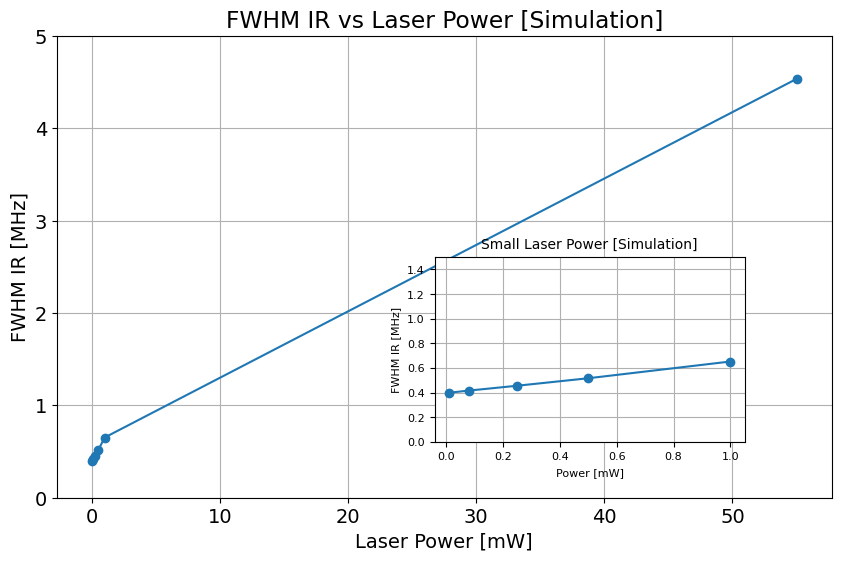

In [34]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(laser_powers, fwhms, marker="o")
ax.set_xlabel("Laser Power [mW]")
ax.set_ylabel("FWHM IR [MHz]")
ax.set_title("FWHM IR vs Laser Power [Simulation]")
ax.set_ylim(0, 5)
# Add an inset plot

inset_ax = inset_axes(ax, width="40%", height="40%", loc="lower right", bbox_to_anchor=(-0.1, 0.1, 1, 1), bbox_transform=ax.transAxes)
filtered_powers = [p for p in laser_powers if p < 4]
filtered_fwhms = [fwhms[i] for i, p in enumerate(laser_powers) if p < 4]

inset_ax.plot(filtered_powers, filtered_fwhms, marker="o")
# inset_ax.set_xlim(0, 4)
inset_ax.set_ylim(0, 1.5)
inset_ax.set_title("Small Laser Power [Simulation]", fontsize=10)
inset_ax.set_xlabel("Power [mW]", fontsize=8)
inset_ax.set_ylabel("FWHM IR [MHz]", fontsize=8)
inset_ax.tick_params(axis='both', which='major', labelsize=8)
inset_ax.grid()
ax.grid()

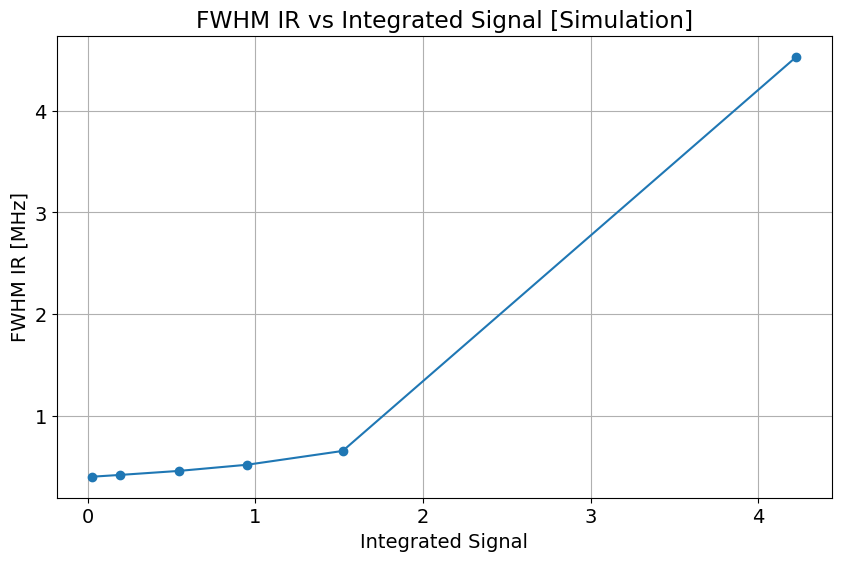

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(integrals, fwhms, marker="o")
ax.set_xlabel("Integrated Signal")
ax.set_ylabel("FWHM IR [MHz]")
ax.set_title("FWHM IR vs Integrated Signal [Simulation]")
ax.grid()
plt.show()

In [36]:
laser_powers, integrals

([0.01, 0.08, 0.25, 0.5, 1, 55],
 [0.02507074631697643,
  0.19194989115306368,
  0.5426624777890727,
  0.9503631453241421,
  1.5207713192728174,
  4.226718651489108])

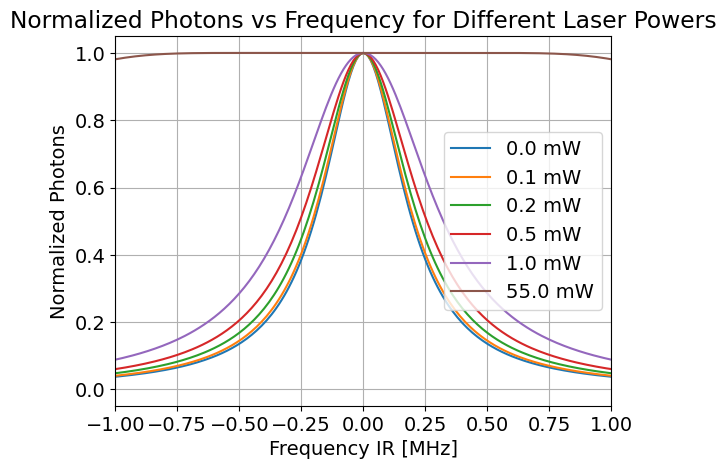

In [52]:
for power, results in results_scan.items():
    frequencies, results = results
    plt.plot(frequencies, results.results/results.results[500], label=f"{power:.1f} mW")
plt.xlim(-1,1)
plt.grid()
plt.xlabel("Frequency IR [MHz]")
plt.ylabel("Normalized Photons")
plt.title("Normalized Photons vs Frequency for Different Laser Powers")
plt.legend()


In [63]:
import pickle
with open("results_scan_freq.pkl", "wb") as f:
    pickle.dump(results_scan, f)

## try fitting 0.25mW data

Text(0.5, 1.0, 'Normalized Signal vs Frequency for 0.25 mW Laser Power')

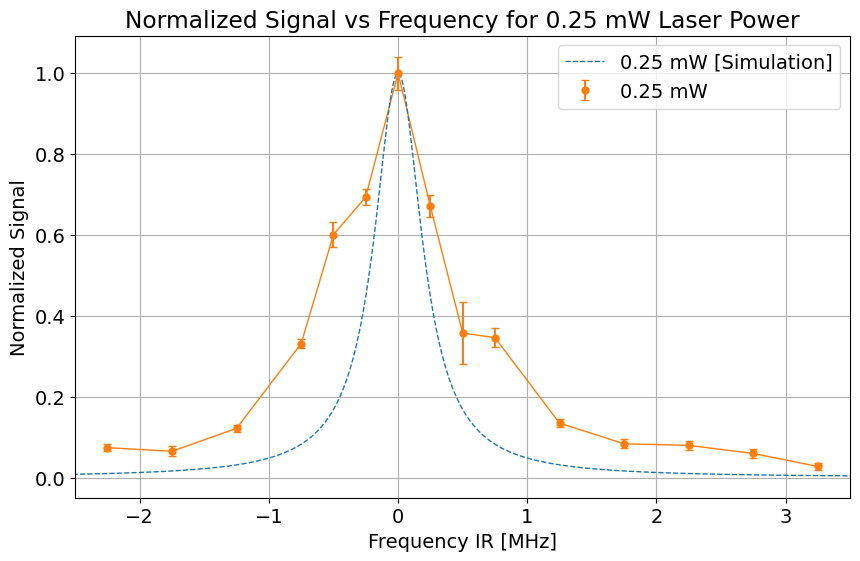

In [ ]:
f_0_25_mw = np.array([
    2156.0, 2156.5, 2157.0, 2157.5, 2157.75,
    2158.0, 2158.25, 2158.5, 2158.75, 2159.0,
    2159.5, 2160.0, 2160.5, 2161.0, 2161.5
]) - 2158.25  # in MHz

d_0_25_mW = np.array([
    0.06591839, 0.05801744, 0.108747, 0.29607686, 0.53676072,
    0.61999784, 0.89347365, 0.59929705, 0.31932618, 0.30906772,
    0.12020088, 0.0745517, 0.07110851, 0.05318794, 0.02447123
])

de_0_25_mW = np.array([
    0.0072489, 0.01101896, 0.00808596, 0.0091603, 0.02717715,
    0.01810224, 0.03630696, 0.02473974, 0.06837207, 0.02107762,
    0.00876078, 0.00993403, 0.00963423, 0.00988509, 0.00730284
])
scale = 1 / d_0_25_mW[f_0_25_mw==0]
d_0_25_mW *= scale
de_0_25_mW *= scale
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(f_0_25_mw, d_0_25_mW, yerr=de_0_25_mW, fmt='o', label='0.25 mW', color='tab:orange', markersize=5, capsize=3)
ax.plot(f_0_25_mw, d_0_25_mW, linestyle="solid", color="tab:orange", linewidth=1)
power = 0.25
ax.plot(results_scan[power][0], results_scan[power][1].results/results_scan[power][1].results[500], label=f"{power:.2f} mW [Simulation]", linestyle="dashed", linewidth=1)

ax.set_xlabel("Frequency IR [MHz]")
ax.set_ylabel("Normalized Signal")
ax.set_xlim(-2.5,3.5)
ax.grid()
ax.legend()
ax.set_title("Normalized Signal vs Frequency for 0.25 mW Laser Power")